# CUB-200 Report Visualizations
Baseline linear probe + Denoising Autoencoder embeddings → MLP classifier

In [40]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
FIGS = Path('reports/figures')
FIGS.mkdir(parents=True, exist_ok=True)
print('Ready.')

Ready.


In [41]:
def parse_eval_summary(path):
    """Read Top-1, Top-5, and dim from an eval_summary.txt file."""
    data = {}
    for line in Path(path).read_text().splitlines():
        if 'Top-1' in line:
            data['top1'] = float(line.split(':')[1].strip().rstrip('%'))
        elif 'Top-5' in line:
            data['top5'] = float(line.split(':')[1].strip().rstrip('%'))
        elif 'Embedding dim' in line:
            data['dim'] = int(line.split(':')[1].strip())
        elif 'epoch' in line.lower():
            try:
                data['epoch'] = int(line.split(':')[1].strip())
            except ValueError:
                pass
    return data

def parse_pca_info(path='embeddings/pca_info.txt'):
    info = {}
    for line in Path(path).read_text().splitlines():
        if ':' in line:
            k, v = line.split(':', 1)
            info[k.strip()] = v.strip()
    return info

def load_result(tag):
    """Load eval summary for a given MLP tag; returns None if not found."""
    p = Path(f'reports/exp_mlp_{tag}/eval_summary.txt')
    return parse_eval_summary(p) if p.exists() else None

# ── load all results ──
baseline = parse_eval_summary('reports/eval_summary.txt')
res      = {tag: load_result(tag)
            for tag in ['512', '256', 'pca', '512_noaug', '256_noaug']}
pca_info = parse_pca_info()

pca_dim       = int(pca_info['n_components'])
pca_var       = pca_info['variance_threshold']
baseline_top1 = baseline['top1']
baseline_top5 = baseline['top5']

for tag, r in res.items():
    if r:
        print(f"{tag:<12}  Top-1={r['top1']:.2f}%  Top-5={r['top5']:.2f}%")
    else:
        print(f"{tag:<12}  (not available)")


512           Top-1=59.58%  Top-5=85.90%
256           Top-1=58.11%  Top-5=86.38%
pca           Top-1=59.73%  Top-5=86.83%
512_noaug     Top-1=62.29%  Top-5=88.45%
256_noaug     Top-1=60.75%  Top-5=87.54%


## 1 — Results Summary

## 1b — Augmentation Comparison (with aug vs without aug)

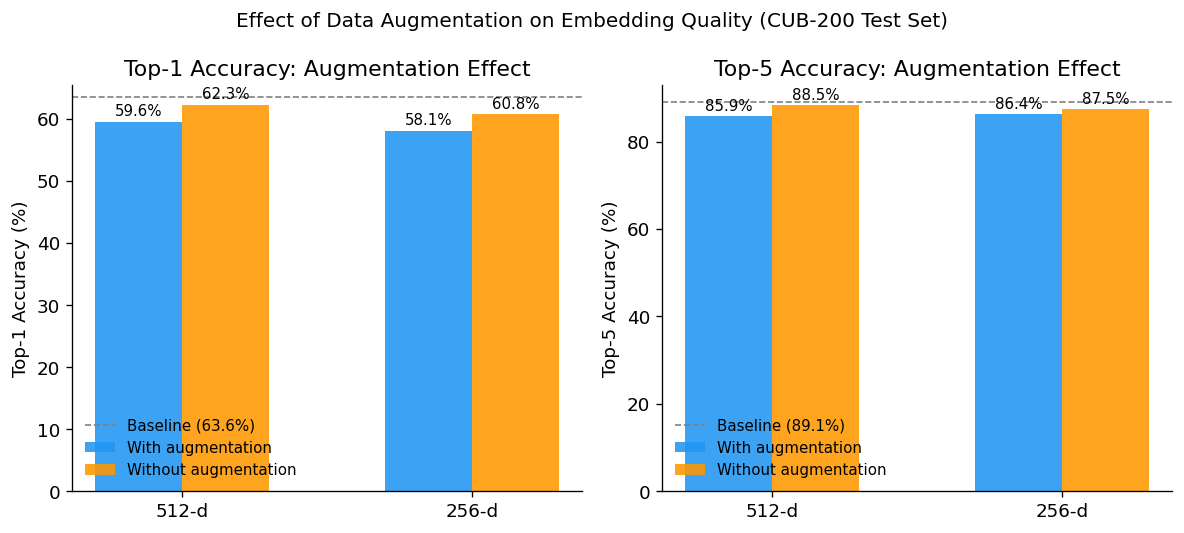

In [42]:
dims    = [512, 256]
aug_c   = '#2196F3'
noaug_c = '#FF9800'
x       = np.arange(len(dims))
w       = 0.3

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=False)

for ax, metric, full in zip(axes, ['top1', 'top5'], ['Top-1', 'Top-5']):
    aug_vals   = [res[str(d)][metric]       if res.get(str(d))             else 0 for d in dims]
    noaug_vals = [res[f'{d}_noaug'][metric] if res.get(f'{d}_noaug')       else 0 for d in dims]

    b1 = ax.bar(x - w/2, aug_vals,   w, label='With augmentation',    color=aug_c,   alpha=0.88)
    b2 = ax.bar(x + w/2, noaug_vals, w, label='Without augmentation', color=noaug_c, alpha=0.88)

    for bar, val in zip(list(b1) + list(b2), aug_vals + noaug_vals):
        if val:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

    ax.axhline(baseline_top1 if metric == 'top1' else baseline_top5,
               color='grey', linestyle='--', linewidth=1,
               label=f'Baseline ({baseline_top1 if metric=="top1" else baseline_top5:.1f}%)')
    ax.set_xticks(x); ax.set_xticklabels([f'{d}-d' for d in dims])
    ax.set_ylabel(f'{full} Accuracy (%)')
    ax.set_title(f'{full} Accuracy: Augmentation Effect')
    ax.legend(frameon=False, fontsize=9)

plt.suptitle('Effect of Data Augmentation on Embedding Quality (CUB-200 Test Set)', fontsize=12)
plt.tight_layout()
fig.savefig(FIGS / 'aug_vs_noaug.png', bbox_inches='tight')
plt.show()


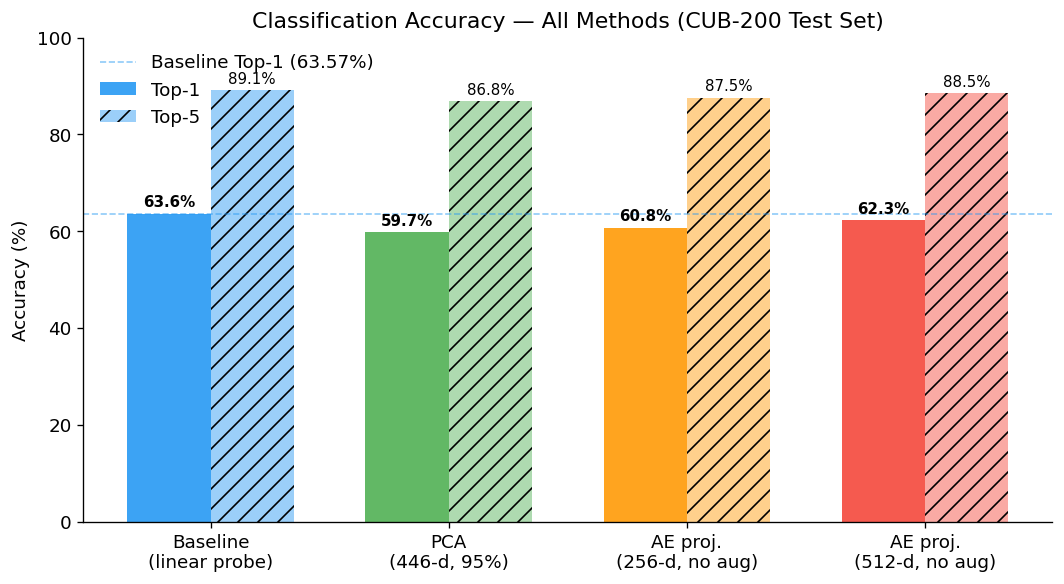

In [43]:
methods = [
    'Baseline\n(linear probe)',
    f'PCA\n({pca_dim}-d, {float(pca_var)*100:.0f}%)',
    'AE proj.\n(256-d, no aug)',
    'AE proj.\n(512-d, no aug)',
]
top1   = [baseline_top1, res['pca']['top1'], res['256_noaug']['top1'], res['512_noaug']['top1']]
top5   = [baseline_top5, res['pca']['top5'], res['256_noaug']['top5'], res['512_noaug']['top5']]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

x = np.arange(len(methods))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, top1, w, label='Top-1', color=colors, alpha=0.88)
bars5 = ax.bar(x + w/2, top5, w, label='Top-5', color=colors, alpha=0.45, hatch='//')

for bar, val in zip(bars1, top1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars5, top5):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax.axhline(baseline_top1, color='#2196F3', linestyle='--', linewidth=1, alpha=0.5,
           label=f'Baseline Top-1 ({baseline_top1:.2f}%)')
ax.set_xticks(x); ax.set_xticklabels(methods)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Classification Accuracy — All Methods (CUB-200 Test Set)')
ax.set_ylim(0, 100)
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig(FIGS / 'results_summary.png', bbox_inches='tight')
plt.show()

## 2 — Autoencoder Reconstruction Loss Curves

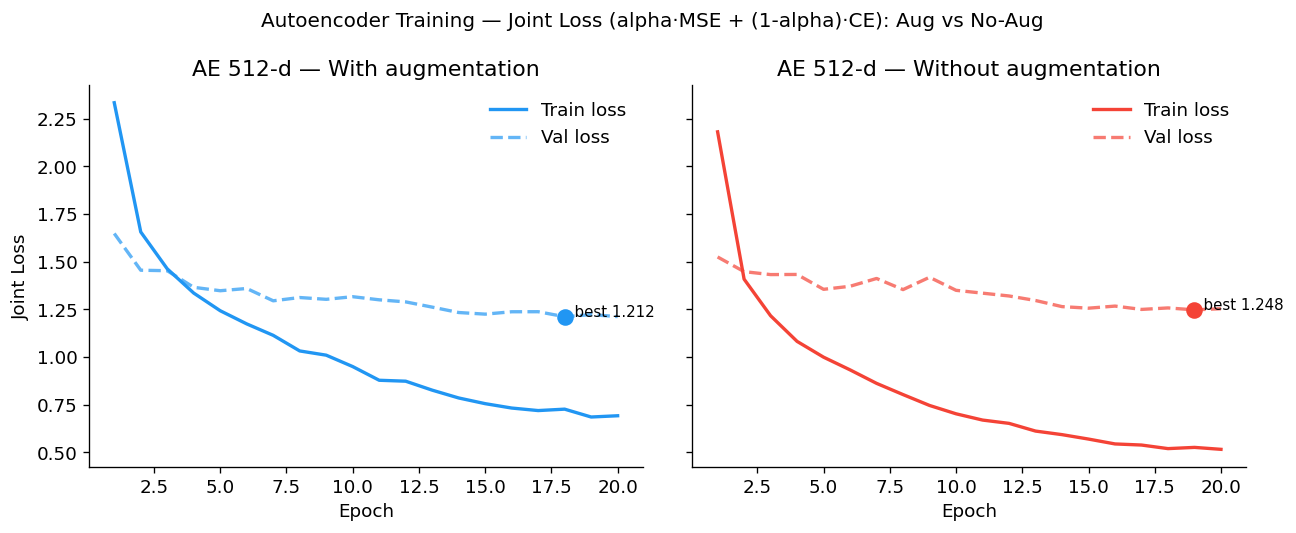

In [44]:
ae512_aug   = pd.read_csv('reports/exp_ae_512/train_log.csv')
ae512_noaug = pd.read_csv('reports/exp_ae_512_noaug/train_log.csv')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for ax, df, label, color in zip(
    axes,
    [ae512_aug, ae512_noaug],
    ['With augmentation', 'Without augmentation'],
    ['#2196F3', '#F44336'],
):
    epochs = df['epoch']
    ax.plot(epochs, df['train_loss'], color=color, linewidth=2, label='Train loss')
    ax.plot(epochs, df['val_loss'],   color=color, linewidth=2, linestyle='--',
            alpha=0.7, label='Val loss')
    best_ep = df.loc[df['val_loss'].idxmin(), 'epoch']
    best_vl = df['val_loss'].min()
    ax.scatter([best_ep], [best_vl], s=80, color=color, zorder=5)
    ax.annotate(f'  best {best_vl:.3f}', (best_ep, best_vl), fontsize=9)
    ax.set_title(f'AE 512-d — {label}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Joint Loss' if ax is axes[0] else '')
    ax.legend(frameon=False)

fig.suptitle('Autoencoder Training — Joint Loss (alpha·MSE + (1-alpha)·CE): Aug vs No-Aug', fontsize=12)
plt.tight_layout()
fig.savefig(FIGS / 'ae_loss_curves.png', bbox_inches='tight')
plt.show()

## 3 — MLP Classifier Training Curves

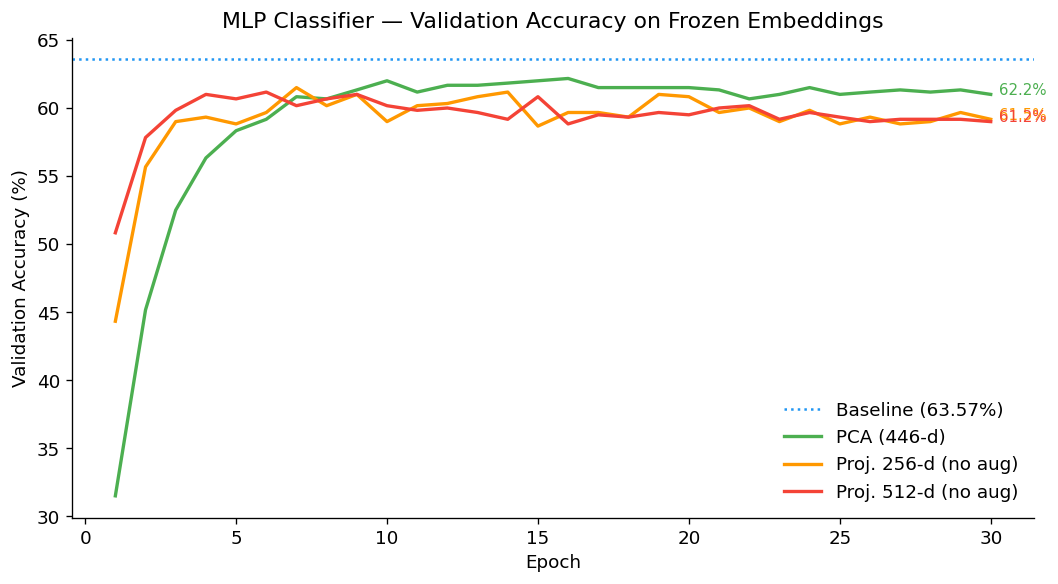

In [45]:
mlp_logs = {
    f'PCA ({pca_dim}-d)':      ('reports/exp_mlp_pca/train_log.csv',         '#4CAF50'),
    'Proj. 256-d (no aug)':    ('reports/exp_mlp_256_noaug/train_log.csv',   '#FF9800'),
    'Proj. 512-d (no aug)':    ('reports/exp_mlp_512_noaug/train_log.csv',   '#F44336'),
}

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(baseline_top1, color='#2196F3', linestyle=':', linewidth=1.5,
           label=f'Baseline ({baseline_top1:.2f}%)')

for label, (path, color) in mlp_logs.items():
    df = pd.read_csv(path)
    ax.plot(df['epoch'], df['val_acc'], color=color, linewidth=2, label=label)
    best = df['val_acc'].max()
    ax.annotate(f'{best:.1f}%', (df['epoch'].iloc[-1], df['val_acc'].iloc[-1]),
                textcoords='offset points', xytext=(5, 0), fontsize=9, color=color)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('MLP Classifier — Validation Accuracy on Frozen Embeddings')
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig(FIGS / 'mlp_val_curves.png', bbox_inches='tight')
plt.show()

## 4 — PCA Explained Variance

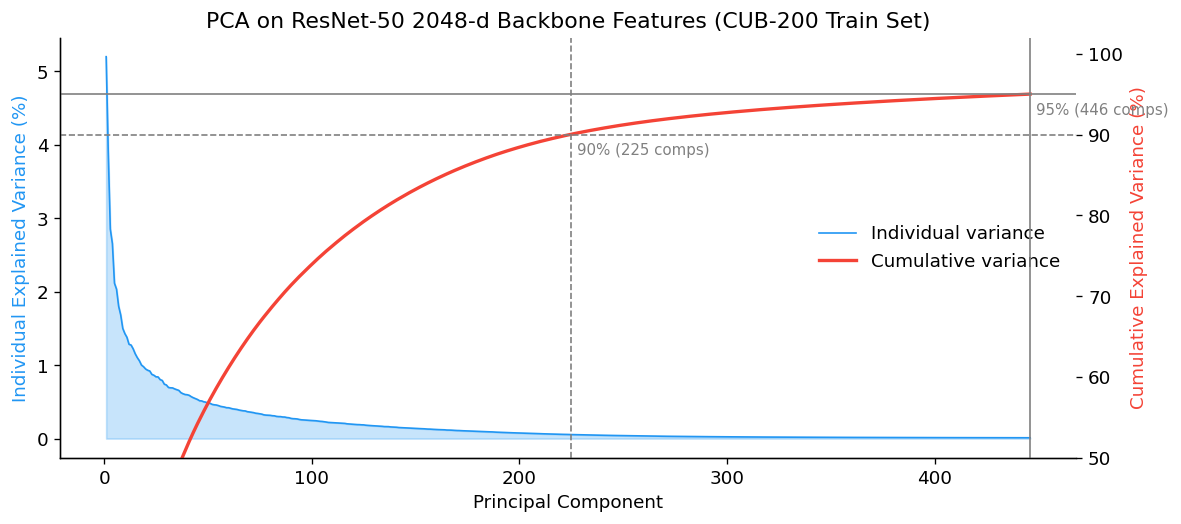

Components for 90% variance: 225
Components for 95% variance: 446


In [46]:
with open('embeddings/pca_model.pkl', 'rb') as f:
    bundle = pickle.load(f)
pca = bundle['pca']

cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
indvar = pca.explained_variance_ratio_ * 100
comps  = np.arange(1, len(cumvar) + 1)

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax2 = ax1.twinx()

ax1.fill_between(comps, indvar, alpha=0.25, color='#2196F3')
ax1.plot(comps, indvar, color='#2196F3', linewidth=1, label='Individual variance')
ax2.plot(comps, cumvar, color='#F44336', linewidth=2, label='Cumulative variance')

for thresh, ls in [(90, '--'), (95, '-')]:
    n = int(np.searchsorted(cumvar, thresh)) + 1
    ax2.axhline(thresh, color='grey', linestyle=ls, linewidth=1)
    ax2.axvline(n,       color='grey', linestyle=ls, linewidth=1)
    ax2.text(n + 3, thresh - 2.5, f'{thresh}% ({n} comps)', fontsize=9, color='grey')

ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Individual Explained Variance (%)', color='#2196F3')
ax2.set_ylabel('Cumulative Explained Variance (%)', color='#F44336')
ax2.set_ylim(50, 102)
ax1.set_title('PCA on ResNet-50 2048-d Backbone Features (CUB-200 Train Set)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='center right')

plt.tight_layout()
fig.savefig(FIGS / 'pca_explained_variance.png', bbox_inches='tight')
plt.show()
print(f'Components for 90% variance: {int(np.searchsorted(cumvar, 90)) + 1}')
print(f'Components for 95% variance: {int(np.searchsorted(cumvar, 95)) + 1}')

## 5 — Per-Class Accuracy Distributions

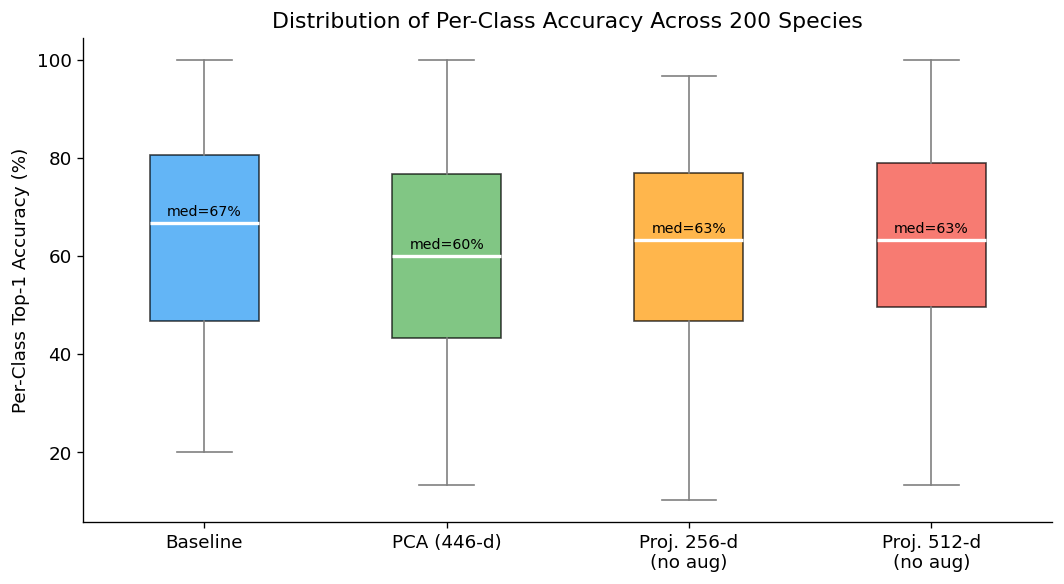

In [47]:
base_df = pd.read_csv('reports/per_class_accuracy.csv')
pca_df  = pd.read_csv('reports/exp_mlp_pca/per_class_accuracy.csv')
d256_df = pd.read_csv('reports/exp_mlp_256_noaug/per_class_accuracy.csv')
d512_df = pd.read_csv('reports/exp_mlp_512_noaug/per_class_accuracy.csv')

accs = [
    base_df['accuracy'].values,
    pca_df['accuracy'].values,
    d256_df['accuracy'].values,
    d512_df['accuracy'].values,
]
box_labels = ['Baseline', f'PCA ({pca_dim}-d)', 'Proj. 256-d\n(no aug)', 'Proj. 512-d\n(no aug)']
colors     = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(accs, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for whisker in bp['whiskers']: whisker.set_color('grey')
for cap     in bp['caps']:     cap.set_color('grey')
for flier   in bp['fliers']:   flier.set(marker='o', markerfacecolor='grey',
                                          markeredgecolor='none', alpha=0.4, markersize=4)

ax.set_xticklabels(box_labels)
ax.set_ylabel('Per-Class Top-1 Accuracy (%)')
ax.set_title('Distribution of Per-Class Accuracy Across 200 Species')
for i, a in enumerate(accs):
    ax.text(i + 1, np.median(a) + 1.5, f'med={np.median(a):.0f}%',
            ha='center', fontsize=8.5)
plt.tight_layout()
fig.savefig(FIGS / 'per_class_distribution.png', bbox_inches='tight')
plt.show()

## 6 — Best and Worst Classes (PCA model)

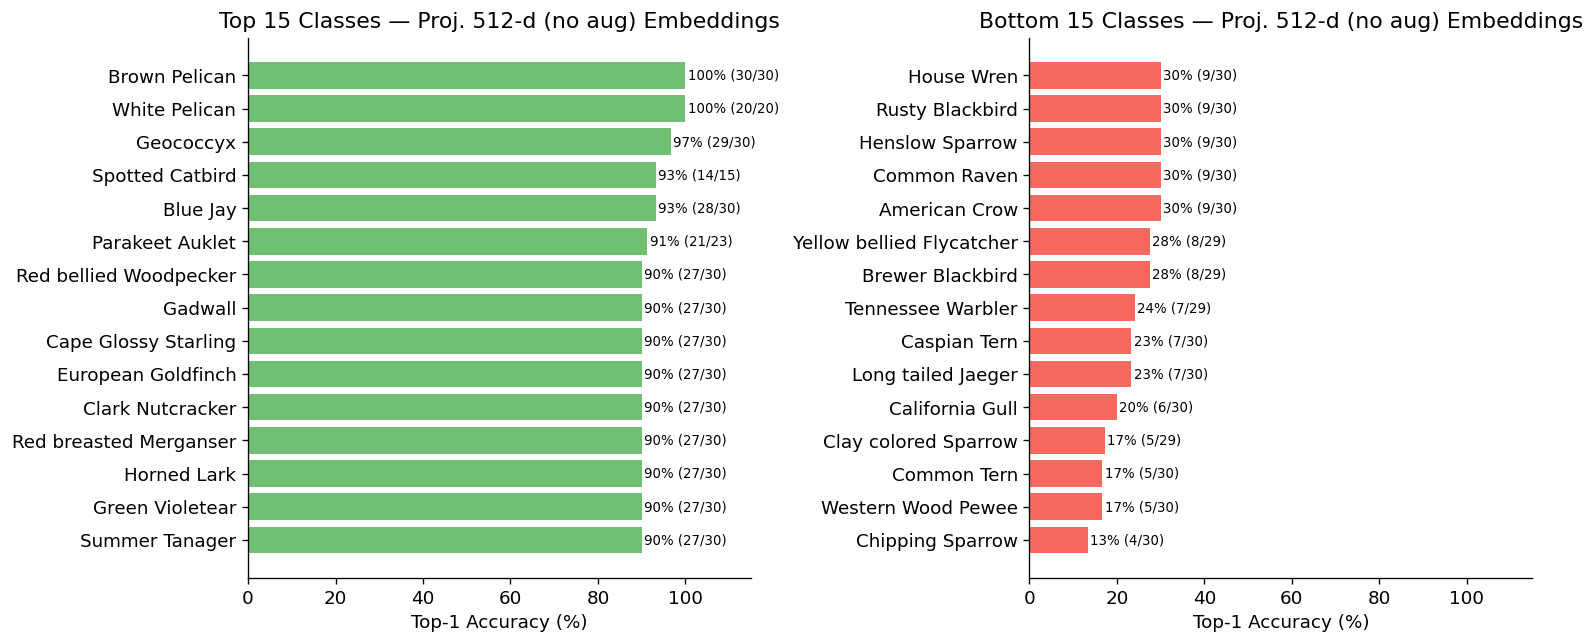

In [48]:
N = 15
df = pd.read_csv('reports/exp_mlp_512_noaug/per_class_accuracy.csv')
df['short_name'] = df['class_name'].str.split('.').str[-1].str.replace('_', ' ')

best  = df.nlargest(N, 'accuracy')
worst = df.nsmallest(N, 'accuracy')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, sub, color, title in [
    (axes[0], best,  '#4CAF50', f'Top {N} Classes'),
    (axes[1], worst, '#F44336', f'Bottom {N} Classes'),
]:
    sub = sub.sort_values('accuracy')
    bars = ax.barh(sub['short_name'], sub['accuracy'], color=color, alpha=0.8)
    for bar, (_, row) in zip(bars, sub.iterrows()):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{row['accuracy']:.0f}% ({int(row['correct'])}/{int(row['total'])})",
                va='center', fontsize=8)
    ax.set_xlim(0, 115)
    ax.set_xlabel('Top-1 Accuracy (%)')
    ax.set_title(f'{title} — Proj. 512-d (no aug) Embeddings')

plt.tight_layout()
fig.savefig(FIGS / 'best_worst_classes.png', bbox_inches='tight')
plt.show()

## 7 — Confusion Matrices (25 most-confused classes)

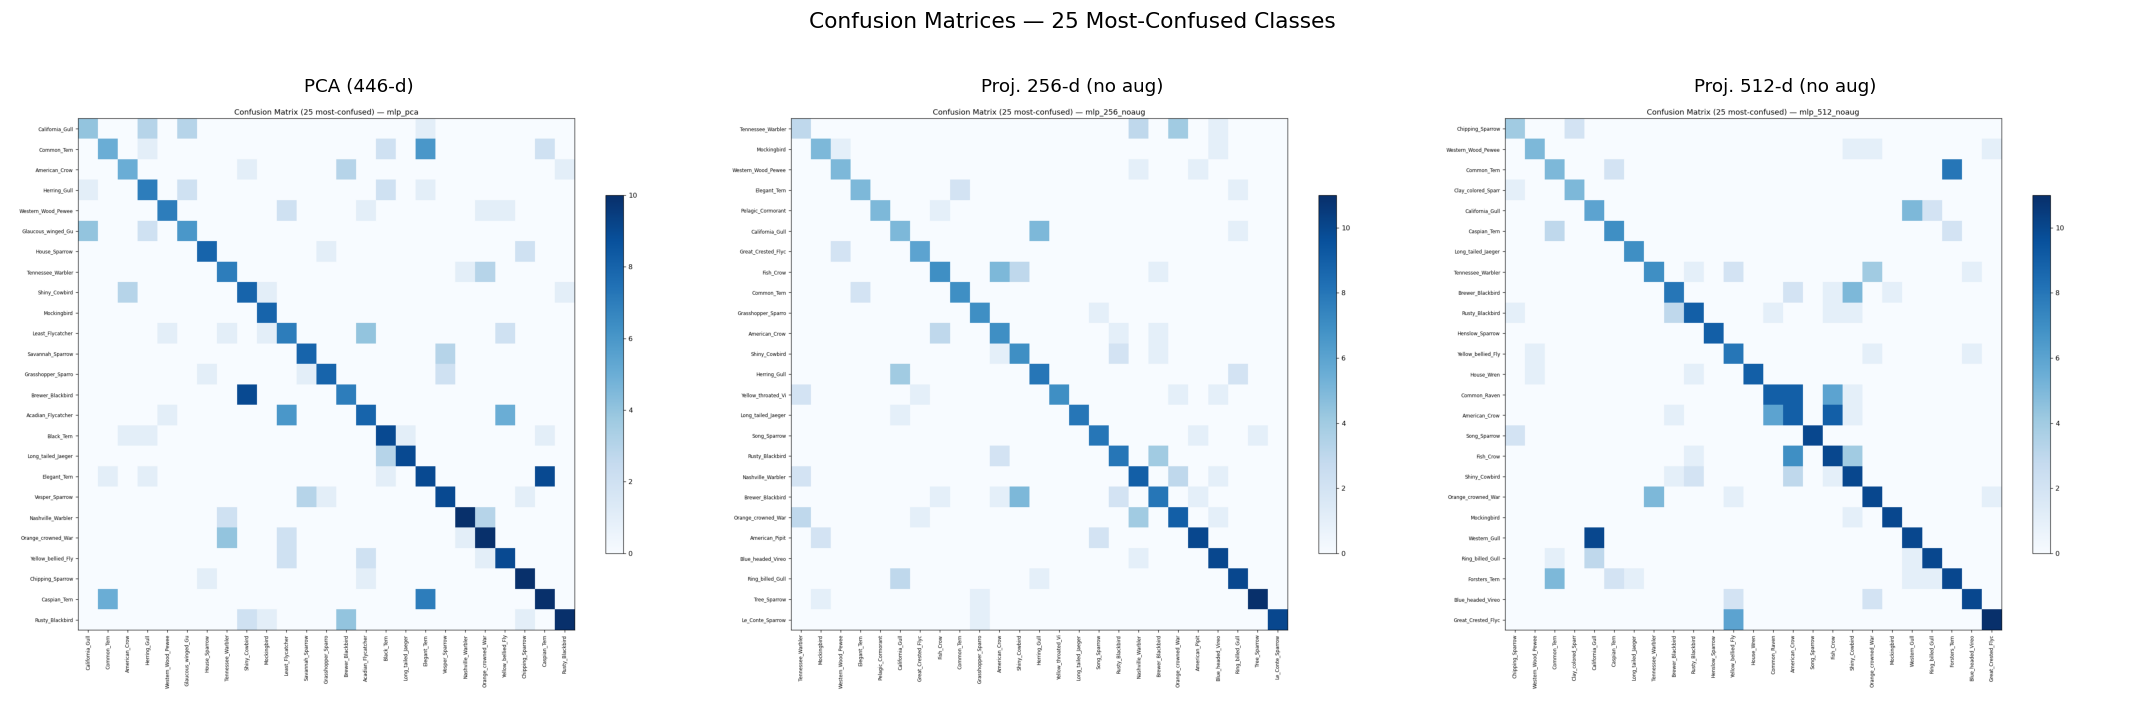

In [49]:
from PIL import Image

cm_paths = {
    f'PCA ({pca_dim}-d)':       'reports/exp_mlp_pca/confusion_matrix.png',
    'Proj. 256-d (no aug)':     'reports/exp_mlp_256_noaug/confusion_matrix.png',
    'Proj. 512-d (no aug)':     'reports/exp_mlp_512_noaug/confusion_matrix.png',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (title, path) in zip(axes, cm_paths.items()):
    img = Image.open(path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=11)

fig.suptitle('Confusion Matrices — 25 Most-Confused Classes', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIGS / 'confusion_matrices_all.png', bbox_inches='tight')
plt.show()

## 8 — Sample Reconstructions from the Autoencoder

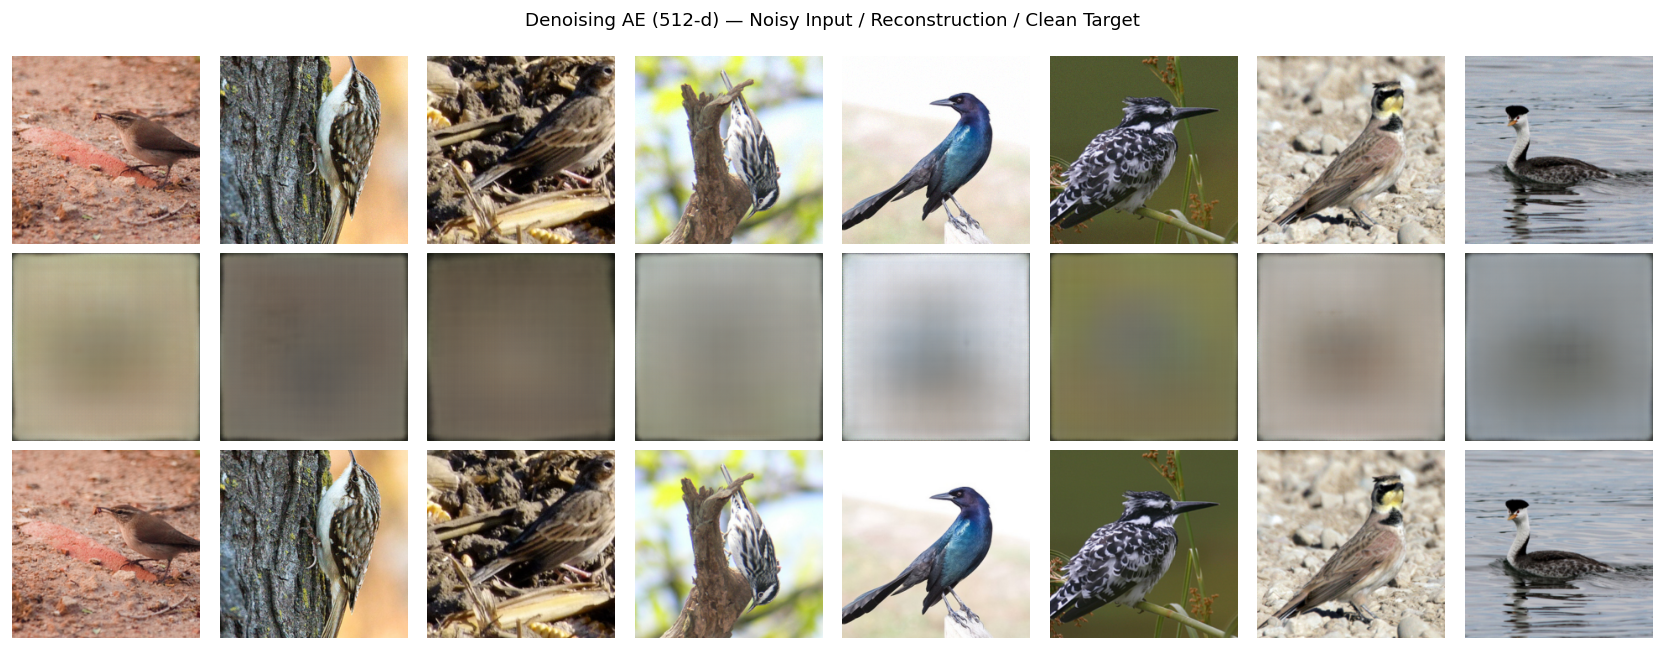

In [50]:
import torch
import yaml
from data import get_ae_transforms
from data.dataset import CUBDataset
from models import AutoEncoder

with open('configs/config.yaml') as f:
    cfg = yaml.safe_load(f)
cfg['ae_training']['num_workers'] = 0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load AE-512 for reconstructions
ckpt  = torch.load('checkpoints/ae_512/best.pt', map_location=device, weights_only=False)
num_classes = ckpt.get('num_classes', None)
model = AutoEncoder(emb_dim=512, pretrained=False, num_classes=num_classes).to(device)
model.load_state_dict(ckpt['state_dict'])
model.eval()

# Get a small batch using AE paired transforms (gives noisy + clean)
root = cfg['dataset']['root']
val_fraction = cfg['dataset']['val_fraction']
seed = cfg['dataset']['seed']
ae_tf = get_ae_transforms(cfg, 'val')
ds = CUBDataset(root, 'test', val_fraction, seed, transform=ae_tf)
loader = torch.utils.data.DataLoader(ds, batch_size=8, shuffle=True, num_workers=0)
(noisy, clean), _ = next(iter(loader))
with torch.no_grad():
    recon, _, _ = model(noisy.to(device))
recon = recon.cpu()

mean = torch.tensor(cfg['preprocessing']['imagenet_mean']).view(3,1,1)
std  = torch.tensor(cfg['preprocessing']['imagenet_std']).view(3,1,1)
def denorm(t): return (t * std + mean).clamp(0, 1)

n = 8
fig, axes = plt.subplots(3, n, figsize=(14, 5.5))
row_labels = ['Noisy input', 'Reconstruction', 'Clean target']
for col in range(n):
    for row, tensor in enumerate([noisy[col], recon[col], clean[col]]):
        img = denorm(tensor).permute(1, 2, 0).numpy()
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
    if col == 0:
        for row in range(3):
            axes[row, 0].set_ylabel(row_labels[row], fontsize=9)

fig.suptitle('Denoising AE (512-d) — Noisy Input / Reconstruction / Clean Target',
             fontsize=11)
plt.tight_layout()
fig.savefig(FIGS / 'ae_reconstructions.png', bbox_inches='tight')
plt.show()